In [72]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [73]:
pd.set_option("display.max_columns",None)
df = pd.read_csv(r'..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [75]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [76]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [77]:
df.drop('customerID',axis=1,inplace=True)

In [86]:
for col in df.columns:
    if not col==int:
        print(col)
        print(df[col].unique())
        print('-'*50)

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen
[0 1]
--------------------------------------------------
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Lengt

In [79]:
df['TotalCharges']=df['TotalCharges'].replace(' ',"0")

In [80]:
df.TotalCharges = df.TotalCharges.astype(float)

In [81]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## insights
- Customer ID removed | not required for model training
- no missing values in dataset
- NAN values in Total Charges Dataset | replaced with 0
- Class Imbalance Identified

In [82]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


## Numerical Feature Distribution Analysis

In [83]:
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
def plot_hist(df,col):
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    col_mean = df[col].mean()
    col_median = df[col].median()
    plt.axvline(col_mean,color='red',linestyle='--',linewidth=1,label = 'mean')
    plt.axvline(col_median,color='blue',linestyle='-',linewidth=1, label= 'median')
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()

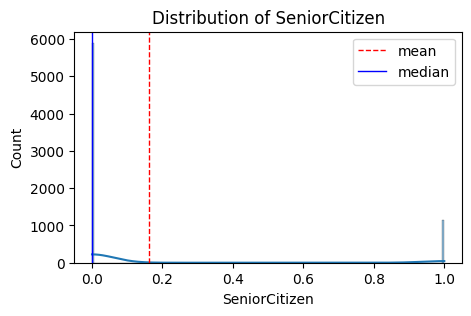

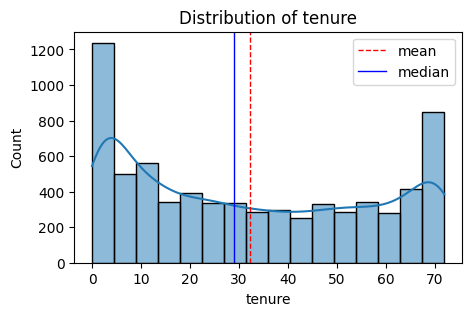

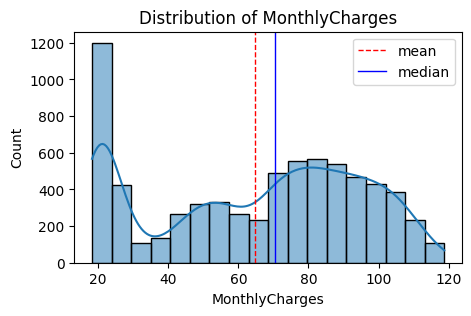

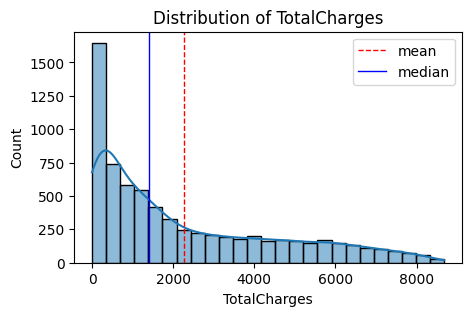

In [84]:
for i in num_cols:
    plot_hist(df,i)

## boxplot for numerical features

In [88]:
def boxy(df,col):
    plt.figure(figsize=(10,8))
    sns.boxplot(y=df[col])
    plt.title(f"Distribution of {col}")
    plt.ylabel(col)
    plt.show

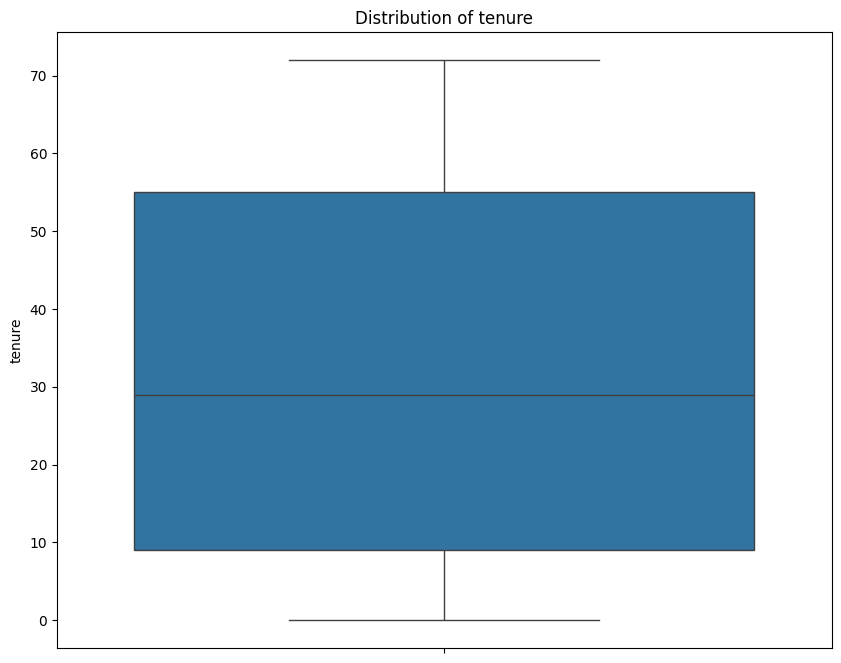

In [90]:
boxy(df,"tenure")

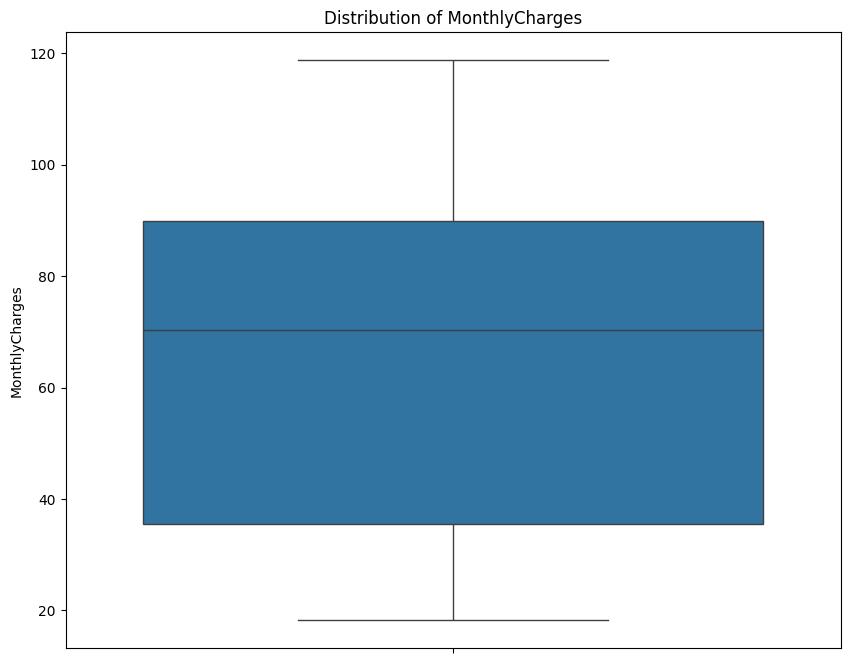

In [91]:
boxy(df,"MonthlyCharges")

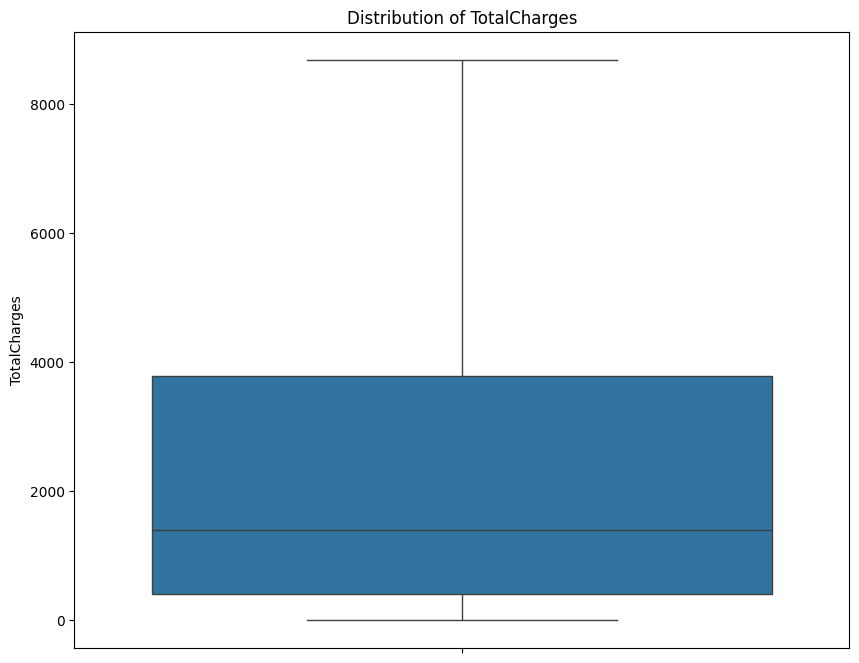

In [93]:
boxy(df,"TotalCharges")

### correlation Heatmap for num_cols

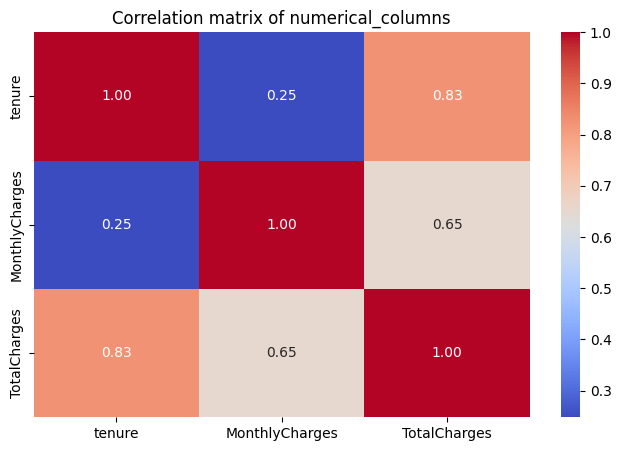

In [100]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation matrix of numerical_columns")
plt.show()

### Working with Categorical Columns

In [108]:
categ = df.select_dtypes(include=['string']).columns.to_list()
categ.append("SeniorCitizen")

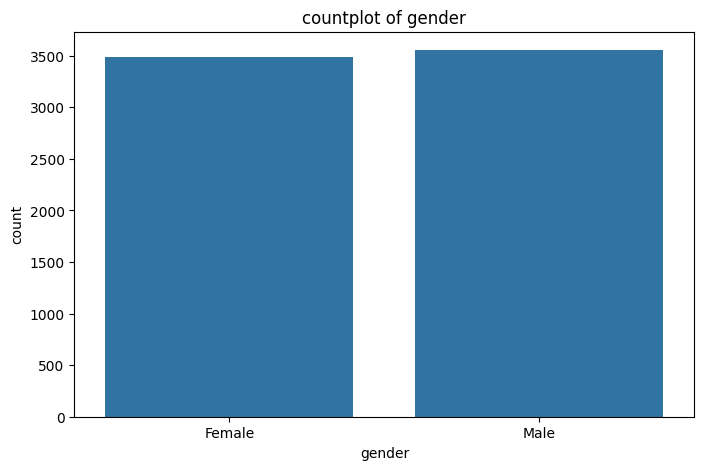

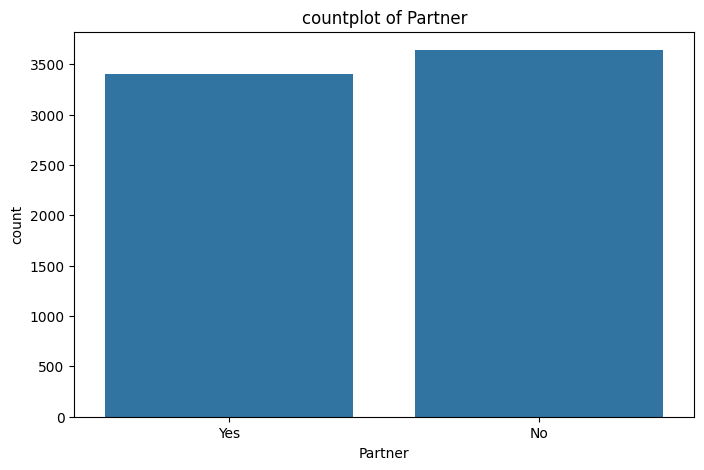

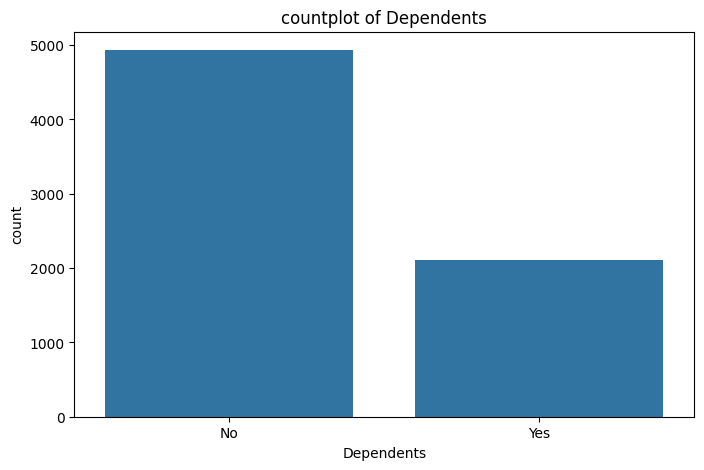

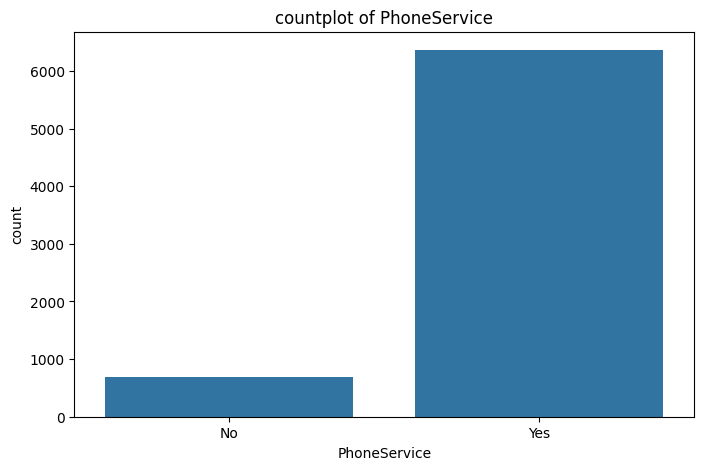

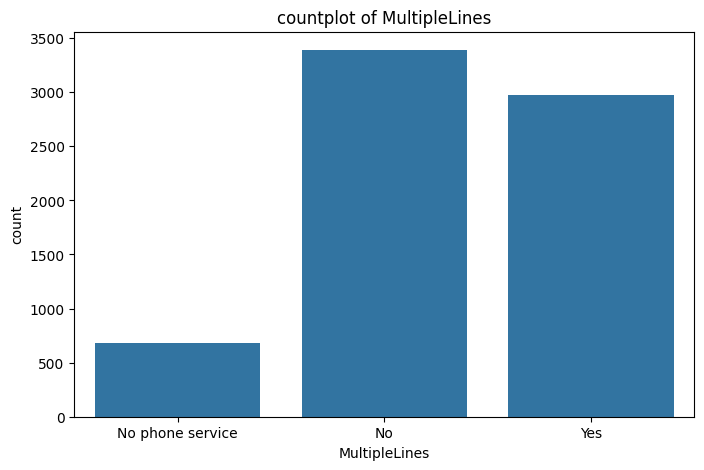

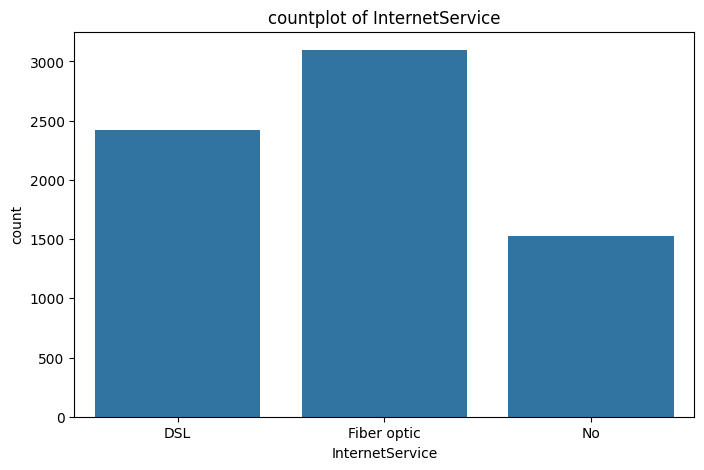

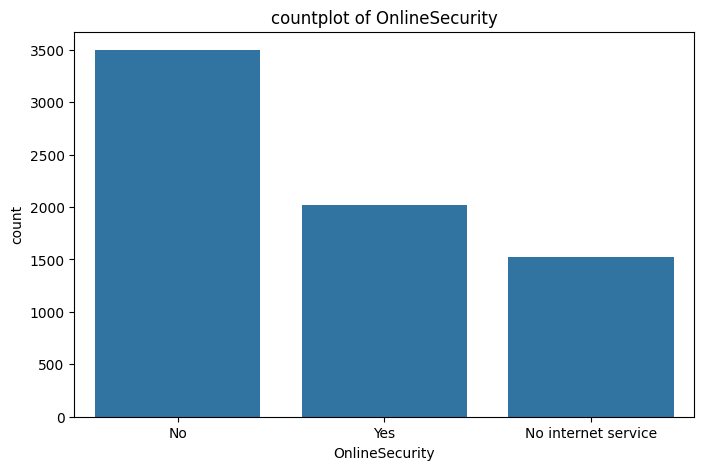

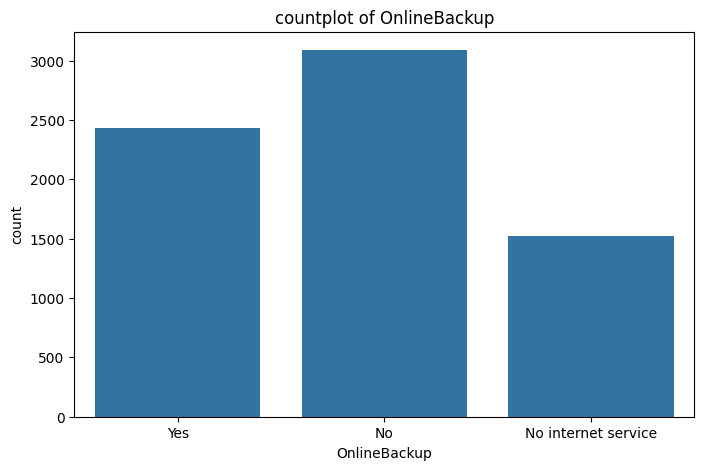

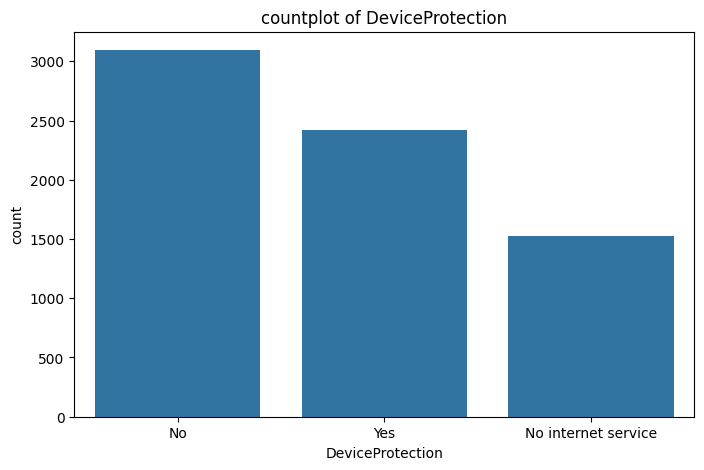

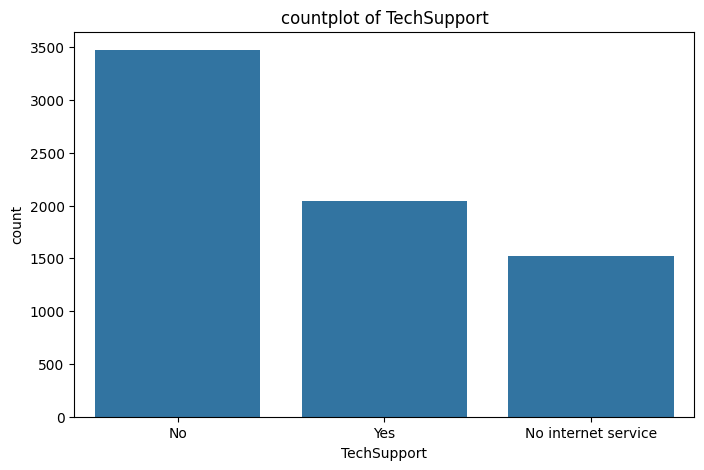

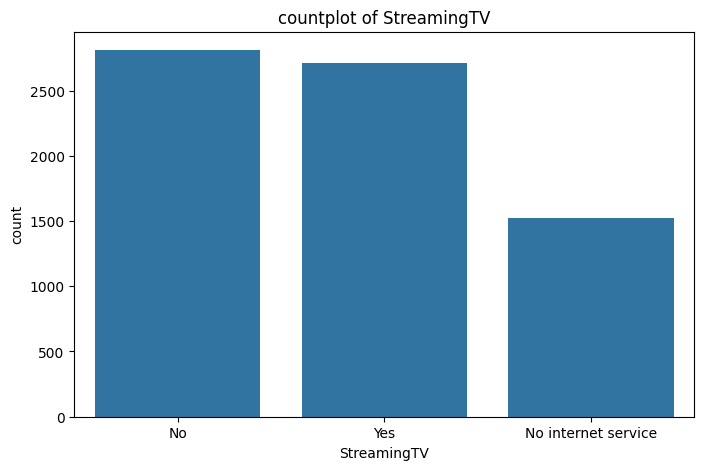

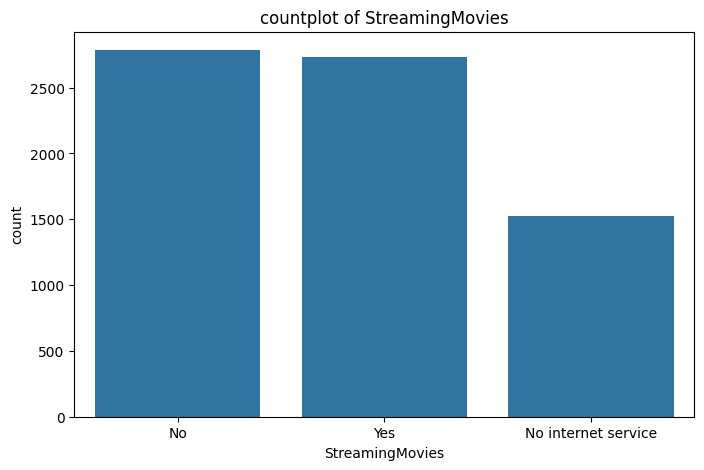

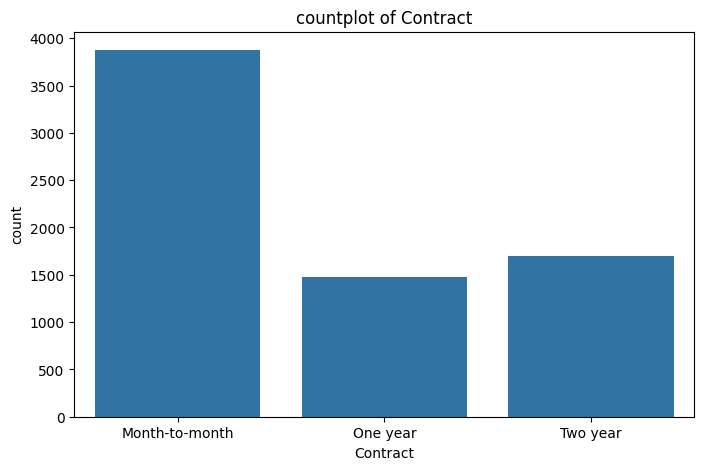

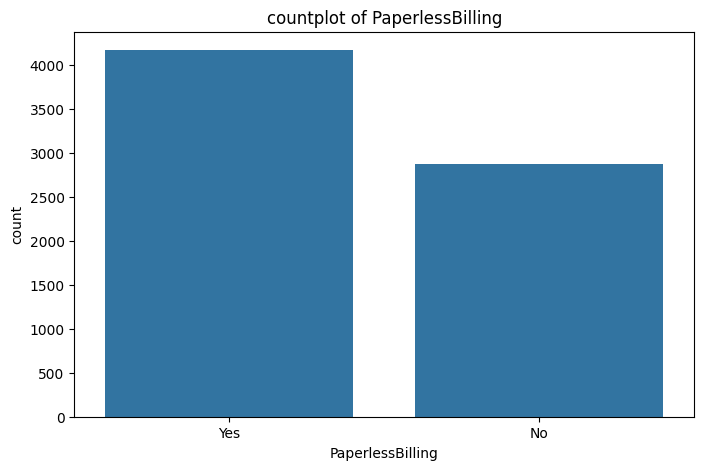

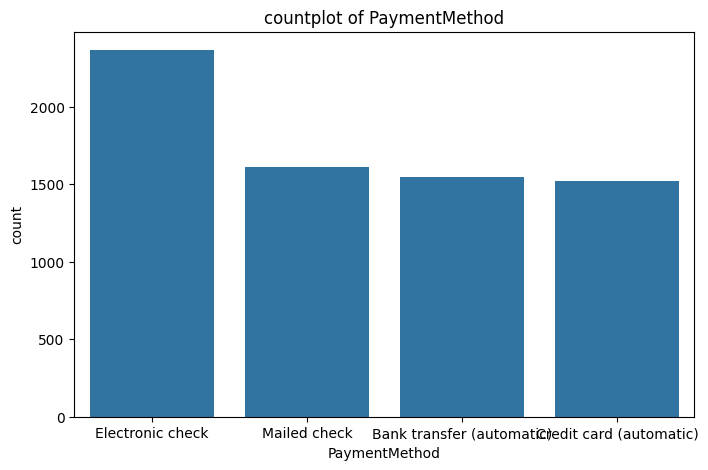

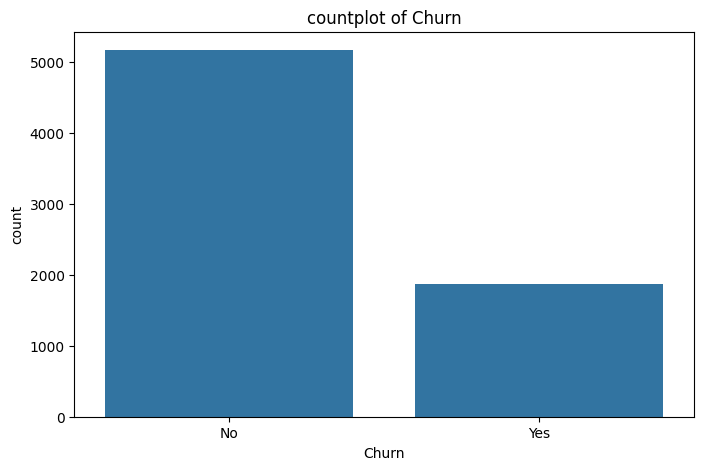

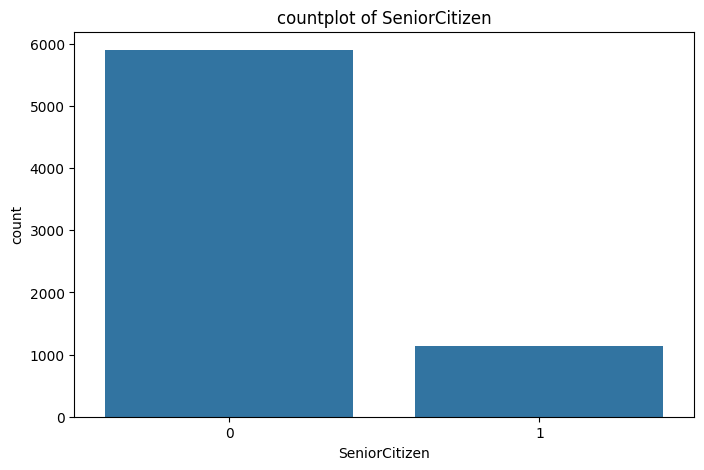

In [109]:
def cnt(df,col):
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[col])
    plt.title(f"countplot of {col}")
    plt.show()
for col in categ:
    cnt(df,col)